# 3.4.1 MMoE 多目标学习

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

点击与转化既共享信号又不完全相同，怎样让每个任务选择不同的共享专家？

## Setup

本 Notebook 的默认真实数据是 **KuaiRand-Pure：真实短视频曝光、点击、长播与多反馈序列**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Ma et al., 2018, MMoE](https://dl.acm.org/doi/10.1145/3219819.3220007)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import (load_movielens, movielens_provenance, load_amazon_2023,
                             amazon_provenance, load_kuairand, kuairand_provenance)
DATASET_KEY = "kuairand"
if DATASET_KEY == "movielens":
    real_ratings, real_movies = load_movielens()
    real_interactions = real_ratings
    REAL_DATASET = movielens_provenance(real_ratings)
elif DATASET_KEY == "amazon-2023":
    real_ratings = load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_provenance(real_ratings)
else:
    real_interactions, real_movies = load_kuairand()
    real_ratings = real_interactions
    REAL_DATASET = kuairand_provenance(real_interactions)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'rows_used': 39098, 'users_used': 128, 'items_used': 2500, 'time_min_utc': '2022-04-09T04:17:39+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0}}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 点击与转化既共享信号又不完全相同，怎样让每个任务选择不同的共享专家？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

MMoE 让所有任务共享一组专家，但为每个任务学习独立 gate。它比 hard sharing 灵活，却仍可能发生专家塌缩、任务梯度冲突和样本空间错位。

**来源：** [Ma et al., 2018, MMoE](https://dl.acm.org/doi/10.1145/3219819.3220007)

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Model Structure & Formula Walkthrough


### 结构：共享专家，任务各自选课

输入 $x\in\mathbb R^m$ 同时进入 $E$ 个专家 $f_e(x)\in\mathbb R^d$。任务 $k$ 的 gate 产生和为 1 的权重：

$$g_k(x)=\mathrm{softmax}(W_{g,k}x),\quad z_k=\sum_{e=1}^E g_{k,e}(x)f_e(x),\quad \hat y_k=\sigma(t_k(z_k)).$$

因此同一条样本上，点击任务可以偏向专家 1，长播任务可以偏向专家 3。总损失是 $L=\sum_k\lambda_kL_k$；$\lambda_k$ 不只是数学常数，也表达业务权衡。形状从专家输出 $[B,E,d]$ 经 task gate $[B,E]$ 变成每任务的 $[B,d]$。

### 公式到代码

`run_mmoe` 用相同曝光行产生 click/long-view 两个真实标签；Torch-RecHub MMOE 的专家、gate、任务塔和逐任务 BCE 都能在源码映射中定位。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

第 $k$ 个任务表示为 $z_k=\sum_e g_{k,e}(x)f_e(x)$。gate 权重经 softmax 后和为 1。专家像擅长不同题型的老师：各任务听同一组老师，但自行决定每位老师占多少。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

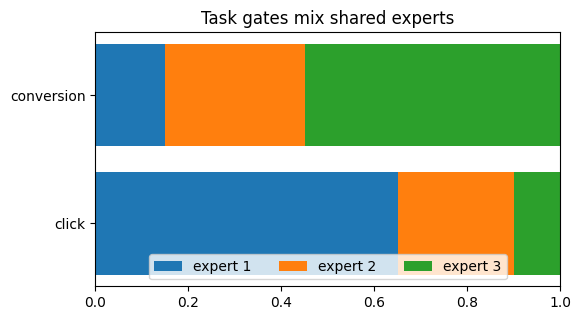

gate sums = [1. 1.]


In [2]:
import numpy as np, matplotlib.pyplot as plt
weights=np.array([[.65,.25,.10],[.15,.30,.55]]); fig,ax=plt.subplots(figsize=(6,3.3)); left=np.zeros(2)
for expert in range(3):
    ax.barh(['click','conversion'],weights[:,expert],left=left,label=f'expert {expert+1}'); left+=weights[:,expert]
ax.set(xlim=(0,1),title='Task gates mix shared experts'); ax.legend(ncol=3,loc='lower center'); plt.show()
print('gate sums =',weights.sum(1))

## Data

KuaiRand-Pure 真实短视频曝光及场景、时段、时长、热度和活跃度特征；两个目标直接使用日志中的 `is_click` 与 `long_view`。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.multi_task.MMOE；full profile 在 TorchEasyRec 配置专家、任务塔、loss 权重、样本掩码和分布式训练。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.3_4_1_mmoe.train")
run_mmoe = chapter_train.run_mmoe

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_mmoe))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_mmoe(epochs: int = 28) -> dict: return _run_multitask("mmoe", epochs)



## Train & Inference

下一格实际执行完整 smoke：固定 seed、构造数据、实例化模型、训练、切换到推理路径并计算测试指标。

In [4]:
result = run_mmoe()
print({'framework': result['framework'], 'dataset': result.get('dataset', {})})
print('inference contract:', '共享特征编码一次，任务 gate 混合专家，各塔输出概率；监控逐任务 AUC、校准、专家利用率与业务价值。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'torch_rechub.models.multi_task.MMOE', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'rows': 8000, 'features': 22, 'tasks': ['observed is_click', 'observed long_view']}}
inference contract: 共享特征编码一次，任务 gate 混合专家，各塔输出概率；监控逐任务 AUC、校准、专家利用率与业务价值。
loss: 1.3193 → 0.8229


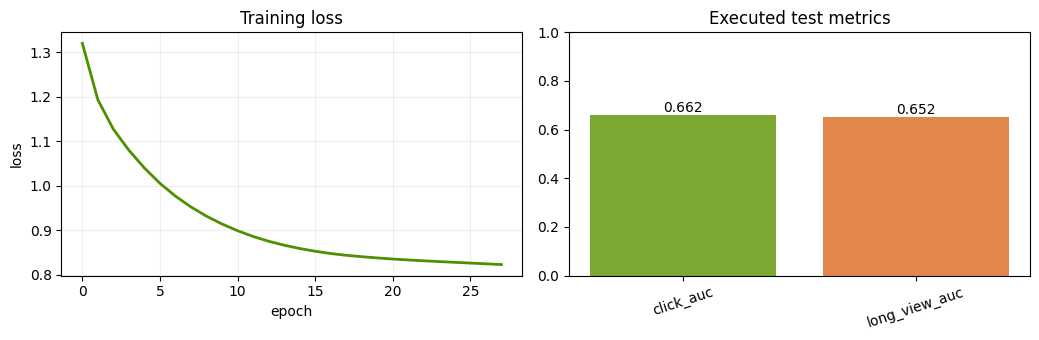

,value
click_auc,0.661867
long_view_auc,0.651726


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'click_auc': result['click_auc'], 'long_view_auc': result['long_view_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

## Test & Results Discussion

In [6]:
display(Markdown(f'''### 本次已执行结果

- 主指标 click_auc = **{result['click_auc']:.4f}**。
- 辅助指标 long_view_auc = **{result['long_view_auc']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** MMoE 不保证胜过独立模型；任务相关性、标签噪声、loss 尺度和采样空间决定是否正迁移。

### 工业边界

共享特征编码一次，任务 gate 混合专家，各塔输出概率；监控逐任务 AUC、校准、专家利用率与业务价值。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 click_auc = **0.6619**。
- 辅助指标 long_view_auc = **0.6517**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **1.3193** 降到 **0.8229**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** MMoE 不保证胜过独立模型；任务相关性、标签噪声、loss 尺度和采样空间决定是否正迁移。

### 工业边界

共享特征编码一次，任务 gate 混合专家，各塔输出概率；监控逐任务 AUC、校准、专家利用率与业务价值。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [7]:
record={
    'algorithm': 'MMoE 多目标学习',
    'primary_metric': 'click_auc', 'primary_value': float(result['click_auc']),
    'secondary_metric': 'long_view_auc', 'secondary_value': float(result['long_view_auc']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '3_4_1_mmoe',
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_3_4','3_4_1_mmoe',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_3_4/3_4_1_mmoe.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [8]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['click_auc']) <= 1
assert np.isfinite(float(result['long_view_auc']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。